# Notebook 00 — Data Preparation (Shared)

Notebook **dùng chung cho cả 3 người**. Mục tiêu:

1. Tải dataset **UIT-VSFC** (Vietnamese Students' Feedback Corpus).
2. Phân tích sơ bộ (statistics, class distribution, length distribution).
3. Tiền xử lý tiếng Việt: lowercase → remove URL/digit/punctuation → tokenize bằng `underthesea` → remove stopwords.
4. Xuất ra `data/processed/{train,dev,test}.csv` để 3 người tái sử dụng.

**Output cuối:** 3 file CSV có cột `text`, `text_clean`, `label`.

In [1]:
import os, re, sys, string, zipfile, io, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
RAW  = ROOT / 'data' / 'raw' / 'UIT-VSFC'
PROC = ROOT / 'data' / 'processed'
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)
print('RAW :', RAW)
print('PROC:', PROC)

RAW : E:\Work\Developer\University's Studies\NLP\NLP-Sentiment\data\raw\UIT-VSFC
PROC: E:\Work\Developer\University's Studies\NLP\NLP-Sentiment\data\processed


## 1. Tải dataset

Pipeline tải data đi theo thứ tự ưu tiên (cái nào có sẵn dùng cái đó):

1. **File raw có sẵn** trong `data/raw/UIT-VSFC/{train,dev,test}/{sents.txt,sentiments.txt}` → load trực tiếp.
2. **HuggingFace Hub** — mirror `uitnlp/vietnamese_students_feedback` (cần `datasets`, mạng).
3. **Fallback sample** (~300 dòng có sẵn trong notebook) — dùng để smoke-test pipeline khi không có mạng.

Tại sao chọn HuggingFace? Vì link Google Drive gốc của UIT thường đổi/hết hạn, còn HF mirror ổn định, tải 1 dòng `load_dataset(...)` là xong.

In [2]:
# Kiểm tra file raw đã có sẵn dạng UIT-VSFC chuẩn chưa (sents.txt + sentiments.txt)
def has_raw_files() -> bool:
    for s in ['train', 'dev', 'test']:
        if not (RAW / s / 'sents.txt').exists():
            return False
        if not (RAW / s / 'sentiments.txt').exists():
            return False
    return True

def try_load_hf(name: str):
    """Thử load 1 HF dataset. Hỗ trợ 2 trường hợp:
      1. Dataset đã convert sang parquet (load thẳng, không cần trust_remote_code).
      2. Dataset còn dùng loader script `.py` (cần trust_remote_code=True).
    Trả về object Dataset hoặc None nếu fail.
    """
    from datasets import load_dataset
    last_err = None
    for kwargs in [{}, {'trust_remote_code': True}]:
        try:
            return load_dataset(name, **kwargs)
        except Exception as e:
            last_err = e
    print(f'  [fail] {name}: {last_err}')
    return None

# Map string label -> int. Cần vì HF auto-convert sang Parquet đôi khi mất
# ClassLabel metadata → cột sentiment trả về 'positive' thay vì 2.
_HF_LABEL_TO_INT = {
    'negative': 0, 'neg': 0,
    'neutral':  1, 'neu': 1,
    'positive': 2, 'pos': 2,
}

def _to_int_label(v) -> int:
    """Chuẩn hoá nhãn về int 0/1/2. Hỗ trợ cả:
      - int / numeric string ('0', '1', '2')
      - tên class ('negative', 'neutral', 'positive')
    Raise ValueError nếu nhãn None / lạ → caller bắt để skip row đó.
    """
    if v is None:
        raise ValueError('Nhãn None')
    if isinstance(v, str):
        s = v.strip().lower()
        if not s:
            raise ValueError('Nhãn rỗng')
        if s in _HF_LABEL_TO_INT:
            return _HF_LABEL_TO_INT[s]
        try:
            return int(s)
        except ValueError as e:
            raise ValueError(f'Không nhận diện được nhãn: {v!r}') from e
    try:
        return int(v)
    except (TypeError, ValueError) as e:
        raise ValueError(f'Không convert được nhãn: {v!r}') from e

def save_hf_to_raw(ds, out_dir: Path) -> None:
    """Xuất HF dataset object ra format chuẩn UIT-VSFC:
        out_dir/{train,dev,test}/sents.txt
        out_dir/{train,dev,test}/sentiments.txt
    
    Lý do làm vậy:
    - Data nằm ngay trong project, không ẩn trong HF cache.
    - Lần chạy sau, has_raw_files() trả True → skip download.
    - Format này tương thích với loader gốc của UIT-VSFC paper.
    """
    # HF có thể đặt tên split là 'validation' thay vì 'dev'. Map về 1 chuẩn.
    name_map = {'train': 'train', 'validation': 'dev', 'dev': 'dev', 'test': 'test'}
    for hf_split, data in ds.items():
        our_name = name_map.get(hf_split)
        if our_name is None:
            continue
        split_dir = out_dir / our_name
        split_dir.mkdir(parents=True, exist_ok=True)
        # Tự dò tên cột (uitnlp dùng 'sentence'/'sentiment'; mirror khác có thể khác).
        cols = data.column_names
        text_col = next((c for c in ['sentence', 'text', 'sent'] if c in cols), cols[0])
        label_col = next((c for c in ['sentiment', 'label', 'labels'] if c in cols), cols[-1])
        # Zip text + label rồi mới filter — đảm bảo 2 file align từng dòng.
        # Skip row có text rỗng hoặc label None / không nhận diện được.
        pairs = []
        bad_text = bad_label = 0
        for raw_text, raw_label in zip(data[text_col], data[label_col]):
            text = str(raw_text).replace('\n', ' ').replace('\r', ' ').strip() if raw_text is not None else ''
            if not text:
                bad_text += 1
                continue
            try:
                label = _to_int_label(raw_label)
            except ValueError:
                bad_label += 1
                continue
            pairs.append((text, str(label)))

        if not pairs:
            print(f'  [SKIP] {our_name}: 0 dòng hợp lệ')
            continue

        sents = [p[0] for p in pairs]
        labels = [p[1] for p in pairs]
        (split_dir / 'sents.txt').write_text('\n'.join(sents), encoding='utf-8')
        (split_dir / 'sentiments.txt').write_text('\n'.join(labels), encoding='utf-8')
        msg = f'  [saved] {split_dir}  ({len(sents)} câu'
        if bad_text or bad_label:
            msg += f'; bỏ {bad_text} câu rỗng, {bad_label} nhãn lạ'
        print(msg + ')')

# Trạng thái sẽ được set sau khi load thành công (raw / sample)
DATA_MODE = None
HF_SOURCE = None

if has_raw_files():
    DATA_MODE = 'raw'
    print('[OK] UIT-VSFC raw files đã có sẵn trong', RAW)
    print('     (Skip download. Xoá thư mục data/raw/UIT-VSFC nếu muốn re-download.)')
else:
    # Thử lần lượt 2 mirror HF cho UIT-VSFC.
    # `uitnlp/...` là gốc, `ura-hcmut/...` là copy sạch hơn.
    print('[INFO] Chưa có raw files. Thử tải từ HuggingFace Hub...')
    for candidate in ['uitnlp/vietnamese_students_feedback', 'ura-hcmut/UIT-VSFC']:
        print(f'  trying: {candidate}')
        ds = try_load_hf(candidate)
        if ds is not None:
            HF_SOURCE = candidate
            print(f'[OK] Tải xong từ {candidate}.')
            print(f'[INFO] Lưu vào {RAW} để lần sau không phải tải lại...')
            save_hf_to_raw(ds, RAW)
            # Verify lại - nếu OK thì coi như đã có raw
            if has_raw_files():
                DATA_MODE = 'raw'
                print('[OK] Đã lưu xong. Từ giờ data nằm trong project.')
            break
    if DATA_MODE is None:
        print('[WARN] Tất cả mirror HF đều fail. Dùng SAMPLE (~300 dòng) để test pipeline.')
        print('       Cần mạng + `pip install datasets` để tải UIT-VSFC full 16k.')
        DATA_MODE = 'sample'

[INFO] Chưa có raw files. Thử tải từ HuggingFace Hub...
  trying: uitnlp/vietnamese_students_feedback


README.md:   0%|          | 0.00/4.79k [00:00<?, ?B/s]

e:\Work\Developer\University's Studies\NLP\NLP-Sentiment\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vohongduc\.cache\huggingface\hub\datasets--uitnlp--vietnamese_students_feedback. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vietnamese_students_feedback.py:   0%|          | 0.00/4.97k [00:00<?, ?B/s]

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'uitnlp/vietnamese_students_feedback' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


...

UIT-VSFC_test.csv:   0%|          | 0.00/279k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11426 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1584 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3166 [00:00<?, ? examples/s]

[OK] Tải xong từ ura-hcmut/UIT-VSFC.
[INFO] Lưu vào E:\Work\Developer\University's Studies\NLP\NLP-Sentiment\data\raw\UIT-VSFC để lần sau không phải tải lại...
  [saved] E:\Work\Developer\University's Studies\NLP\NLP-Sentiment\data\raw\UIT-VSFC\train  (11426 câu)
  [saved] E:\Work\Developer\University's Studies\NLP\NLP-Sentiment\data\raw\UIT-VSFC\dev  (1583 câu; bỏ 1 câu rỗng, 0 nhãn lạ)
  [saved] E:\Work\Developer\University's Studies\NLP\NLP-Sentiment\data\raw\UIT-VSFC\test  (3166 câu)
[OK] Đã lưu xong. Từ giờ data nằm trong project.


In [4]:
# === Fallback sample dataset (chỉ chạy nếu không có UIT-VSFC thật) ===
# Cân bằng 3 lớp 0/1/2 cho mục đích smoke-test pipeline.
SAMPLE_NEG = [
    'Giảng viên dạy quá nhanh, sinh viên không kịp hiểu.',
    'Bài giảng buồn ngủ, nội dung lặp lại nhiều.',
    'Phòng học nóng, máy chiếu hỏng liên tục.',
    'Đề thi quá khó so với những gì đã học.',
    'Thầy ít quan tâm câu hỏi của sinh viên.',
    'Tài liệu môn học cũ, không cập nhật.',
    'Lịch học bị thay đổi liên tục gây bất tiện.',
    'Bài tập nhóm phân chia không công bằng.',
    'Cách chấm điểm thiếu minh bạch.',
    'Wifi trong lớp kém, học online rất khó chịu.',
]
SAMPLE_NEU = [
    'Môn học có nội dung như mô tả trong syllabus.',
    'Giảng viên giảng dạy theo slide có sẵn.',
    'Lớp học diễn ra đúng giờ quy định.',
    'Đề thi gồm phần lý thuyết và bài tập.',
    'Bài giảng được thu âm và đăng tải sau buổi học.',
    'Sinh viên có thể chọn đề tài tiểu luận.',
    'Lịch nộp bài tập được công bố trên hệ thống.',
    'Phòng học có máy chiếu và bảng trắng.',
    'Tài liệu được chia sẻ qua email lớp.',
    'Buổi thảo luận tổ chức vào cuối kỳ.',
]
SAMPLE_POS = [
    'Giảng viên giảng rất dễ hiểu và nhiệt tình.',
    'Môn học cực kỳ bổ ích, em học được nhiều kiến thức.',
    'Thầy luôn sẵn sàng giải đáp thắc mắc của sinh viên.',
    'Slide bài giảng đẹp, trực quan, dễ tiếp thu.',
    'Cách dạy hài hước, không gây buồn ngủ.',
    'Bài tập thực tế, áp dụng được cho dự án cá nhân.',
    'Đánh giá công bằng, có feedback chi tiết cho từng sinh viên.',
    'Em rất thích phong cách giảng dạy của cô.',
    'Môn học truyền cảm hứng nghiên cứu cho sinh viên.',
    'Tài liệu phong phú, cập nhật mới nhất.',
]

def build_sample(n_per_class_train=70, n_per_class_dev=10, n_per_class_test=20, seed=42):
    rng = random.Random(seed)
    def make(sents, label, n):
        out = []
        for _ in range(n):
            base = rng.choice(sents)
            # nhiễu nhẹ để tránh trùng lặp 100%
            if rng.random() < 0.3: base = base + ' Ổn.'
            if rng.random() < 0.2: base = 'Theo em, ' + base
            out.append((base, label))
        return out
    train, dev, test = [], [], []
    for lbl, sents in [(0, SAMPLE_NEG), (1, SAMPLE_NEU), (2, SAMPLE_POS)]:
        train += make(sents, lbl, n_per_class_train)
        dev   += make(sents, lbl, n_per_class_dev)
        test  += make(sents, lbl, n_per_class_test)
    rng.shuffle(train); rng.shuffle(dev); rng.shuffle(test)
    df_train = pd.DataFrame(train, columns=['text','label'])
    df_dev   = pd.DataFrame(dev,   columns=['text','label'])
    df_test  = pd.DataFrame(test,  columns=['text','label'])
    return df_train, df_dev, df_test

In [5]:
# Helper load từ raw files theo format UIT-VSFC gốc
def load_uitvsfc_split(split: str) -> pd.DataFrame:
    base = RAW / split
    sents = (base / 'sents.txt').read_text(encoding='utf-8').splitlines()
    labels = (base / 'sentiments.txt').read_text(encoding='utf-8').splitlines()
    assert len(sents) == len(labels), f'Length mismatch in {split}'
    return pd.DataFrame({'text': sents, 'label': [int(x) for x in labels]})

# Build 3 DataFrame từ raw files (đã có sẵn hoặc vừa tải về & lưu xuống raw).
# Vì cell 3 đã chuẩn hoá: nếu HF tải OK thì lưu thành raw, nên ở đây chỉ còn 2 mode.
if DATA_MODE == 'raw':
    df_train = load_uitvsfc_split('train')
    df_dev = load_uitvsfc_split('dev')
    df_test = load_uitvsfc_split('test')
    if HF_SOURCE:
        DATA_SOURCE = f'UIT-VSFC (raw, tải lần đầu từ {HF_SOURCE})'
    else:
        DATA_SOURCE = 'UIT-VSFC (raw files đã có sẵn)'
else:  # sample
    df_train, df_dev, df_test = build_sample()
    DATA_SOURCE = 'SAMPLE (~300 rows, demo only)'

print(f'Source: {DATA_SOURCE}')
print(f'Train: {df_train.shape}  Dev: {df_dev.shape}  Test: {df_test.shape}')
print(f'Total : {len(df_train) + len(df_dev) + len(df_test)} câu')
df_train.head()

Source: UIT-VSFC (raw, tải lần đầu từ ura-hcmut/UIT-VSFC)
Train: (11426, 2)  Dev: (1583, 2)  Test: (3166, 2)
Total : 16175 câu


,text,label
0,slide giáo trình đầy đủ .,2
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2
2,đi học đầy đủ full điểm chuyên cần .,0
3,chưa áp dụng công nghệ thông tin và các thiết ...,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2


## 2. Phân tích sơ bộ

Lấy số liệu để viết báo cáo (class distribution, độ dài câu, top từ vựng).

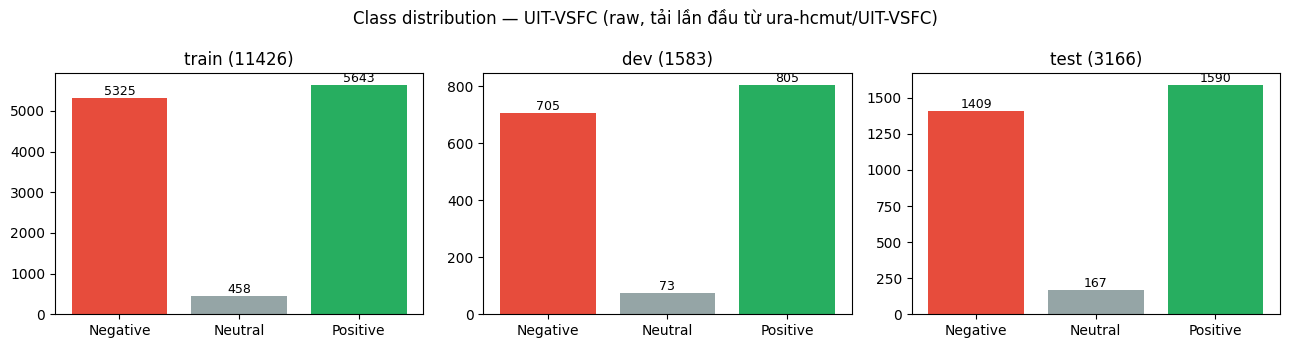

In [6]:
LABEL_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, df) in zip(axes, [('train', df_train), ('dev', df_dev), ('test', df_test)]):
    counts = df['label'].value_counts().sort_index()
    ax.bar([LABEL_NAMES[i] for i in counts.index], counts.values, color=['#e74c3c','#95a5a6','#27ae60'])
    ax.set_title(f'{name} ({len(df)})')
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=9)
plt.suptitle(f'Class distribution — {DATA_SOURCE}')
plt.tight_layout(); plt.show()

Độ dài câu (số từ thô):
  min=2  max=159  mean=14.3  median=11  p95=33


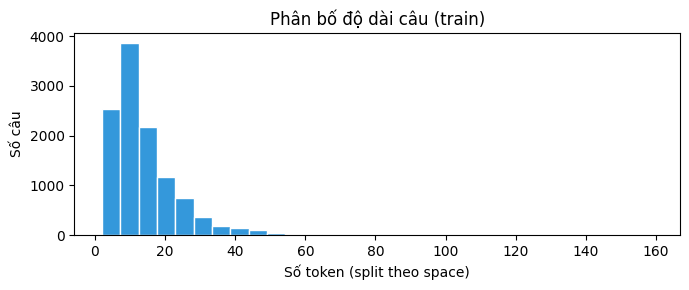

In [8]:
lengths = df_train['text'].str.split().str.len()
print('Độ dài câu (số từ thô):')
print(f'  min={lengths.min()}  max={lengths.max()}  mean={lengths.mean():.1f}  median={lengths.median():.0f}  p95={lengths.quantile(0.95):.0f}')

plt.figure(figsize=(7, 3))
plt.hist(lengths, bins=30, color='#3498db', edgecolor='white')
plt.title('Phân bố độ dài câu (train)')
plt.xlabel('Số token (split theo space)'); plt.ylabel('Số câu')
plt.tight_layout(); plt.show()

## 2.5. Data Augmentation (tuỳ chọn — bật khi muốn tăng dữ liệu)

UIT-VSFC chuẩn có **16.175 câu** đã đủ cho final project. Nhưng nếu muốn tăng dữ liệu để model robust hơn (đặc biệt cho lớp Neutral hiếm), có thể **gộp thêm Vietnamese subset từ `clapAI/MultiLingualSentiment`** (~127k câu, 3 lớp giống UIT-VSFC).

**Trade-off:**

| Mục | Chỉ UIT-VSFC (~16k) | + clapAI augment (~143k) |
|---|---|---|
| Train size | 11.426 | ~100.000+ |
| Thời gian train | Phút | Vài phút – vài chục phút |
| Domain match | Khớp (student feedback) | Pha trộn (e-commerce + social) |
| Generalization | Trung bình | Tốt hơn ở câu lạ |

**Quy tắc khoa học:**
- **CHỈ augment train**; **dev/test giữ thuần UIT-VSFC** để metric phản ánh đúng task.
- Augment có thể tạo **domain shift** — Tiki/Shopee review khác hẳn feedback sinh viên. Nếu thấy metric tụt → tắt augment.

Đặt `USE_AUGMENT = True` ở cell dưới để bật.

In [9]:
# --- Toggle bật/tắt augmentation ------------------------------------------
USE_AUGMENT = False          # đặt True nếu muốn dùng clapAI để tăng dữ liệu
AUG_MAX = 80_000             # số câu VI tối đa lấy thêm (đặt nhỏ nếu RAM yếu)

# File cache trong data/raw — lần sau bật USE_AUGMENT sẽ load thẳng, không tải lại.
AUG_CACHE = RAW.parent / 'clapAI_vi.csv'

# Map text/string label về 0/1/2 (UIT-VSFC convention)
_LABEL_MAP = {
    'negative': 0, 'neg': 0, '0': 0, 0: 0,
    'neutral':  1, 'neu': 1, '1': 1, 1: 1,
    'positive': 2, 'pos': 2, '2': 2, 2: 2,
}

def _norm_label(v):
    """Chuẩn hoá label về 0/1/2 hoặc None nếu không hợp lệ."""
    if isinstance(v, str):
        v = v.strip().lower()
    return _LABEL_MAP.get(v)

def _stream_clapai(max_n: int) -> pd.DataFrame:
    """Stream clapAI/MultiLingualSentiment, lọc câu tiếng Việt, tối đa max_n dòng.
    Tách hàm để gọn + dễ test riêng. Stream tránh tải full 3M-row dataset.
    """
    from datasets import load_dataset
    from tqdm.auto import tqdm
    stream = load_dataset('clapAI/MultiLingualSentiment', split='train', streaming=True)
    rows = []
    pbar = tqdm(stream, desc='filter vi', unit='ex')
    for ex in pbar:
        if (ex.get('language') or ex.get('lang') or '').lower() != 'vi':
            continue
        txt = ex.get('text') or ex.get('sentence') or ''
        lbl = _norm_label(ex.get('label'))
        if not txt or lbl is None:
            continue
        rows.append({'text': str(txt), 'label': lbl})
        if len(rows) >= max_n:
            break
        if len(rows) % 1000 == 0:
            pbar.set_postfix(vi=len(rows))
    pbar.close()
    return pd.DataFrame(rows)

if not USE_AUGMENT:
    print('[SKIP] USE_AUGMENT=False, giữ nguyên UIT-VSFC.')
else:
    # --- Bước 1: ưu tiên đọc từ cache trong data/raw nếu đã có --------------
    if AUG_CACHE.exists():
        df_aug = pd.read_csv(AUG_CACHE)
        print(f'[OK] Đọc augment cache từ {AUG_CACHE} ({len(df_aug)} câu)')
    else:
        print('[INFO] Chưa có cache. Tải clapAI VI (streaming) ...')
        try:
            df_aug = _stream_clapai(AUG_MAX)
            # Lưu cache vào data/raw để lần sau khỏi tải lại
            df_aug.to_csv(AUG_CACHE, index=False, encoding='utf-8')
            print(f'[OK] Đã lưu cache: {AUG_CACHE} ({len(df_aug)} câu)')
        except Exception as e:
            print('[WARN] Tải clapAI fail, giữ nguyên UIT-VSFC:', e)
            df_aug = None

    # --- Bước 2: merge vào train (nếu đã có df_aug) -------------------------
    if df_aug is not None and len(df_aug) > 0:
        print('  Phân bố lớp augment:',
              df_aug['label'].value_counts().sort_index().to_dict())

        # Loại trùng (đề phòng câu UIT-VSFC bị duplicate trong augment)
        before = len(df_aug)
        df_aug = df_aug[~df_aug['text'].isin(df_train['text'])].reset_index(drop=True)
        print(f'  Loại trùng với UIT-VSFC train: {before - len(df_aug)} câu')

        # CHỈ gộp vào train; dev/test giữ nguyên
        df_train_orig_size = len(df_train)
        df_train = pd.concat([df_train, df_aug], ignore_index=True)
        DATA_SOURCE = DATA_SOURCE + f' + clapAI VI ({len(df_aug)})'
        print(f'[OK] Train: {df_train_orig_size} -> {len(df_train)} câu')

[SKIP] USE_AUGMENT=False, giữ nguyên UIT-VSFC.


## 3. Tiền xử lý văn bản tiếng Việt

Pipeline:
1. **Lowercase**
2. **Remove URLs / digits / punctuation / emoji**
3. **Word segmentation** (`underthesea`) — quan trọng vì tiếng Việt có từ ghép.
4. **Remove stopwords** (danh sách rút gọn)
5. **Strip whitespace**

In [7]:
from underthesea import word_tokenize

VN_STOPWORDS = set([
    'và','là','của','có','được','trong','cho','khi','thì','đã','đang','sẽ','cũng',
    'này','đó','kia','để','như','với','mà','một','các','những','rất','quá','lắm',
    'ạ','nhé','nha','ơi','thế','vậy','rồi','nữa','lại','chỉ','vẫn','còn','hơn','bị',
    'từ','về','trên','dưới','ngoài','bên','theo','vào','ra','lên','xuống'
])

PUNCT = string.punctuation + '“”‘’–—…•·«»\u200b'
URL_RE = re.compile(r'http\S+|www\.\S+')
DIGIT_RE = re.compile(r'\d+')
SPACE_RE = re.compile(r'\s+')
EMOJI_RE = re.compile(
    '[\U0001F300-\U0001F9FF\U0001FA00-\U0001FAFF\u2600-\u27BF]+'
)

def basic_clean(text: str) -> str:
    t = str(text).lower()
    t = URL_RE.sub(' ', t)
    t = EMOJI_RE.sub(' ', t)
    t = DIGIT_RE.sub(' ', t)
    t = t.translate(str.maketrans('', '', PUNCT))
    t = SPACE_RE.sub(' ', t).strip()
    return t

def vn_tokenize(text: str) -> str:
    # underthesea trả về tokens cách nhau bằng dấu cách, từ ghép nối bằng '_'
    return word_tokenize(text, format='text')

def remove_stopwords(text: str) -> str:
    return ' '.join(w for w in text.split() if w not in VN_STOPWORDS)

def preprocess(text: str) -> str:
    t = basic_clean(text)
    t = vn_tokenize(t)
    t = remove_stopwords(t)
    return t

# Demo
for s in [
    'Sản phẩm RẤT tốt, giao hàng nhanh!!! 🚀',
    'Giảng viên dạy quá nhanh, không kịp hiểu :(',
    'Lớp học diễn ra lúc 7h30 sáng.'
]:
    print('IN :', s)
    print('OUT:', preprocess(s))
    print('-' * 60)

IN : Sản phẩm RẤT tốt, giao hàng nhanh!!! 🚀
OUT: sản_phẩm tốt giao hàng nhanh
------------------------------------------------------------
IN : Giảng viên dạy quá nhanh, không kịp hiểu :(
OUT: giảng_viên dạy nhanh không kịp hiểu
------------------------------------------------------------
IN : Lớp học diễn ra lúc 7h30 sáng.
OUT: lớp_học diễn lúc h sáng
------------------------------------------------------------


In [8]:
from tqdm.auto import tqdm
tqdm.pandas(desc='preprocessing')

df_train['text_clean'] = df_train['text'].progress_map(preprocess)
df_dev['text_clean']   = df_dev['text'].progress_map(preprocess)
df_test['text_clean']  = df_test['text'].progress_map(preprocess)

df_train.head()

preprocessing:   0%|          | 0/11426 [00:00<?, ?it/s]

preprocessing:   0%|          | 0/1583 [00:00<?, ?it/s]

preprocessing:   0%|          | 0/3166 [00:00<?, ?it/s]

,text,label,text_clean
0,slide giáo trình đầy đủ .,2,slide giáo_trình đầy_đủ
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,nhiệt_tình giảng_dạy gần_gũi sinh_viên
2,đi học đầy đủ full điểm chuyên cần .,0,đi học đầy_đủ full_điểm chuyên cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,chưa áp_dụng công_nghệ_thông_tin thiết_bị hỗ_t...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,thầy giảng bài hay nhiều bài_tập ví_dụ ngay lớp


## 4. Lưu ra `data/processed/`

In [9]:
for name, df in [('train', df_train), ('dev', df_dev), ('test', df_test)]:
    out = PROC / f'{name}.csv'
    df[['text', 'text_clean', 'label']].to_csv(out, index=False, encoding='utf-8')
    print(f'[saved] {out}  rows={len(df)}')

with open(PROC / 'meta.json', 'w', encoding='utf-8') as f:
    json.dump({
        'source': DATA_SOURCE,
        'labels': LABEL_NAMES,
        'train': len(df_train), 'dev': len(df_dev), 'test': len(df_test)
    }, f, ensure_ascii=False, indent=2)
print('[done]')

[saved] E:\Work\Developer\University's Studies\NLP\NLP-Sentiment\data\processed\train.csv  rows=11426
[saved] E:\Work\Developer\University's Studies\NLP\NLP-Sentiment\data\processed\dev.csv  rows=1583
[saved] E:\Work\Developer\University's Studies\NLP\NLP-Sentiment\data\processed\test.csv  rows=3166
[done]


Sau khi chạy xong notebook này → 3 file CSV trong `data/processed/`. Cả 3 người đều load từ đó.